In [200]:
# Imports
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import sleap_io
import glob

### PATHS AND CONSTANTS

In [201]:
# Experiment params, paths and constants

experiment = 'abcEphysPilot01'
session = '2026-04-14T141851Z_calibrateBeforeAprilExperiments'
arena = 'AEON3'
chunk = '2026-04-14T14-00-00'


camera_a = 'CameraTop'
camera_b_list = ['CameraSouth', 'CameraNorth', 'CameraEast', 'CameraWest']

# base_path_ceph = '/Volumes/aeon/aeon/data/raw'
base_path_personal = '/Users/zosiasus/Documents/Aeon3_SLEAP'
label_base_path = base_path_personal + f'/aeon3_data/{experiment}_sleap_for_card/models/card_inference_results/predictions'

# video_path = base_path_ceph + f'/data/raw/{arena}/{experiment}/{session}'
# video_path_a = base_path_ceph + f'/{camera_a}/{camera_a}_{chunk}.avi'
results_dir = base_path_personal + f'/frame_mapping_output/{experiment}/'
os.makedirs(results_dir, exist_ok=True)

In [202]:
# # SLEAP labeled data
# labeled_video_a = label_base_path + f'/{camera_a}_{chunk}.avi_{experiment}_unseen_labels.v001.slp.260416_160641.predictions.slp'
# labels_a = sleap_io.load_file(labeled_video_a)

### OBTAIN CARD CORNER COORDINATES

In [203]:
# get card corner coordinates from the .slp labels with confidence score
def extract_card_points_with_conf(inst):
    pts = {}
    conf_dict = {}

    for p in inst.points:
        name = p[4]
        xy = np.array(p[0], dtype=np.float32)
        conf = float(p[1])

        pts[name] = xy
        conf_dict[name] = conf

    return pts, conf_dict

# get card corner coordinates from the .slp labels, quality control and assign to each frame, output -> df with card corner coord.
def get_card_points(labels, conf_thresh=0.8, verbose=True):
    frame_dict = {}

    removed = {
        "no_instances": [],
        "low_confidence": [],
        "missing_corners": []
    }

    for lf in labels:

        if len(lf.instances) == 0:
            removed["no_instances"].append(lf.frame_idx)
            continue

        inst = lf.instances[0]

        pts_dict, conf = extract_card_points_with_conf(inst)

        # check the 'quality' of the extracted card by req. 4 corners and also setting a confidence score cut off
        required = ["corner_1", "corner_2", "corner_3", "corner_4"]
        if not all(k in pts_dict for k in required):
            removed["missing_corners"].append(lf.frame_idx)
            continue

        if not is_good_card_from_sleap(conf, conf_thresh):
            removed["low_confidence"].append(lf.frame_idx)
            continue

        pts = np.array([
            pts_dict["corner_1"],
            pts_dict["corner_2"],
            pts_dict["corner_3"],
            pts_dict["corner_4"],
        ], dtype=np.float32)

        frame_dict[lf.frame_idx] = pts

    if verbose:
        total = len(labels)
        kept = len(frame_dict)

        print("\n===== CARD EXTRACTION SUMMARY =====")
        print(f"Total frames:        {total}")
        print(f"Kept frames:         {kept}")
        print(f"Removed (no inst):   {len(removed['no_instances'])}")
        print(f"Removed (low conf):  {len(removed['low_confidence'])}")
        print(f"Removed (missing):   {len(removed['missing_corners'])}")
        print("===================================\n")

    return frame_dict, removed

# check the 'quality' of the extracted card by req. 4 corners and also setting a confidence score cut off
def is_good_card_from_sleap(conf, threshold=0.8):
    required = ["corner_1", "corner_2", "corner_3", "corner_4"]

    for k in required:
        if k not in conf:
            return False
        if conf[k] < threshold:
            return False

    return True



        

### COMPUTE HOMOLOGY BETWEEN FRAME PAIRS

In [204]:
def is_nearly_collinear(pts, thresh=0.01):
    hull = cv2.convexHull(pts.astype(np.float32))
    area = cv2.contourArea(hull)
    x, y, w, h = cv2.boundingRect(hull)
    bbox_area = w * h

    if bbox_area == 0:
        return True

    return (area / bbox_area) < thresh


def is_good_card_pair(pts_a, pts_b, min_area=500):
    pts_a = pts_a.astype(np.float32)
    pts_b = pts_b.astype(np.float32)

    area_a = cv2.contourArea(pts_a)
    area_b = cv2.contourArea(pts_b)

    if area_a < min_area or area_b < min_area:
        return False

    if is_nearly_collinear(pts_b):
        return False

    return True


def compute_global_homography(frames_a, frames_b, max_frames=500):

    all_a = []
    all_b = []

    common_frames = list(set(frames_a.keys()) & set(frames_b.keys()))

    print(f"Common frames: {len(common_frames)}")

    valid_frames = []

    # --- pairwise filtering ---
    for f in common_frames:
        pts_a = frames_a[f]
        pts_b = frames_b[f]

        if pts_a.shape != (4, 2) or pts_b.shape != (4, 2):
            continue

        if np.any(np.isnan(pts_a)) or np.any(np.isnan(pts_b)):
            continue

        if not is_good_card_pair(pts_a, pts_b):
            continue

        valid_frames.append(f)

    print(f"Valid paired frames: {len(valid_frames)}")

    if len(valid_frames) < 4:
        return None, None

    # --- optional subsampling ---
    if len(valid_frames) > max_frames:
        valid_frames = random.sample(valid_frames, max_frames)
        print(f"Subsampled to: {len(valid_frames)} frames")

    # --- build correspondence set ---
    for f in valid_frames:
        all_a.append(frames_a[f])
        all_b.append(frames_b[f])

    all_a = np.vstack(all_a)  # (N*4, 2)
    all_b = np.vstack(all_b)

    if len(all_a) < 8:
        return None, None

    # --- compute homography ---
    H, mask = cv2.findHomography(
        all_b,
        all_a,
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0
    )

    if H is None:
        return None, None

    # --- debug info ---
    if mask is not None:
        inlier_ratio = mask.sum() / len(mask)
        print(f"Inlier ratio: {inlier_ratio:.2f}")

    return H, mask

In [205]:
# def compute_global_homography(frames_a, frames_b):

#     all_a = []
#     all_b = []

#     common_frames = set(frames_a.keys()) & set(frames_b.keys())

#     for f in common_frames:
#         pts_a = frames_a[f]
#         pts_b = frames_b[f]

#         # safety check
#         if pts_a.shape != (4, 2) or pts_b.shape != (4, 2):
#             continue

#         if np.any(np.isnan(pts_a)) or np.any(np.isnan(pts_b)):
#             continue

#         all_a.append(pts_a)
#         all_b.append(pts_b)

#     all_a = np.vstack(all_a)  # (N*4, 2)
#     all_b = np.vstack(all_b)

#     if len(all_a) < 8:
#         return None, None

#     # high level - how to warp camera B into camera A
#     H, mask = cv2.findHomography(
#         all_b,
#         all_a,
#         method=cv2.RANSAC,
#         ransacReprojThreshold=3.0
#     )

#     return H, mask

### DEBUGGING FUN

In [210]:
def debug_frame_pairs(frames_a, frames_b, H=None, max_print=10):
    import numpy as np

    common_frames = sorted(set(frames_a.keys()) & set(frames_b.keys()))
    print(f"\nTotal common frames: {len(common_frames)}")

    errors = []
    bad_frames = []

    for f in common_frames:
        pts_a = frames_a[f]
        pts_b = frames_b[f]

        if pts_a.shape != (4, 2) or pts_b.shape != (4, 2):
            continue

        if np.any(np.isnan(pts_a)) or np.any(np.isnan(pts_b)):
            continue

        # --- basic geometry sanity ---
        area_a = cv2.contourArea(pts_a.astype(np.float32))
        area_b = cv2.contourArea(pts_b.astype(np.float32))

        if area_a < 10 or area_b < 10:
            bad_frames.append((f, "tiny_area"))
            continue

        # --- reprojection error if H exists ---
        if H is not None:
            pts_b_proj = cv2.perspectiveTransform(
                pts_b.reshape(-1, 1, 2).astype(np.float32),
                H
            ).reshape(-1, 2)

            err = np.linalg.norm(pts_a - pts_b_proj, axis=1).mean()
            errors.append((f, err))

            if err > 10:  # large error = suspicious
                bad_frames.append((f, f"high_err={err:.2f}"))

    # --- stats ---
    if errors:
        err_vals = np.array([e for _, e in errors])
        print("\nReprojection error stats:")
        print(f"Mean: {err_vals.mean():.2f}")
        print(f"Median: {np.median(err_vals):.2f}")
        print(f"Max: {err_vals.max():.2f}")
        print(f"Min: {err_vals.min():.2f}")

    # --- print worst offenders ---
    print(f"\nBad frames found: {len(bad_frames)}")

    for bf in bad_frames[:max_print]:
        print("Frame:", bf)

    return errors, bad_frames

def inspect_sample_pairs(frames_a, frames_b, n=5):
    common_frames = list(set(frames_a) & set(frames_b))[:n]

    for f in common_frames:
        print(f"\nFrame {f}")
        print("A:")
        print(frames_a[f])
        print("B:")
        print(frames_b[f])

import cv2
import matplotlib.pyplot as plt

def draw_points(img, pts, color):
    img = img.copy()
    pts = pts.astype(int)

    for i, (x, y) in enumerate(pts):
        cv2.circle(img, (x, y), 6, color, -1)
        cv2.putText(img, str(i), (x+5, y+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return img


def visualize_bad_frame_pairs(
    frames_a,
    frames_b,
    bad_frames,
    H,
    n=5
):

    print("\n===== VISUAL DEBUG (SLEAP ONLY) =====")

    shown = 0

    for frame_idx, reason in bad_frames:

        if shown >= n:
            break

        if frame_idx not in frames_a or frame_idx not in frames_b:
            continue

        pts_a = frames_a[frame_idx].astype(np.float32)
        pts_b = frames_b[frame_idx].astype(np.float32)

        # project B → A
        pts_b_proj = cv2.perspectiveTransform(
            pts_b.reshape(-1, 1, 2),
            H.astype(np.float64)
        ).reshape(-1, 2)

        plt.figure(figsize=(10, 4))

        # --- Camera A ---
        plt.subplot(1, 2, 1)
        plt.scatter(pts_a[:, 0], pts_a[:, 1], c='g', label="A (GroundTruth)")
        plt.scatter(pts_b_proj[:, 0], pts_b_proj[:, 1], c='r', label="B → A")
        plt.title(f"Camera A | Frame {frame_idx}")
        plt.gca().invert_yaxis()
        plt.axis("equal")
        plt.legend()

        # --- Camera B ---
        plt.subplot(1, 2, 2)
        plt.scatter(pts_b[:, 0], pts_b[:, 1], c='b', label="B")
        plt.title(f"Camera B | {reason}")
        plt.gca().invert_yaxis()
        plt.axis("equal")
        plt.legend()

        plt.tight_layout()
        plt.show()

        shown += 1

In [207]:
def run_sleap_homography(
    labels_a,
    labels_b,
    camera_b,
    reproj_thresh=5.0,
    min_inliers=10,
    debug=True
):

    # --- extract frames ---
    frames_a, _ = get_card_points(labels_a)
    frames_b, _ = get_card_points(labels_b)

    # --- compute homography ---
    H, mask = compute_global_homography(frames_a, frames_b)

    if H is None:
        print("Not enough valid correspondences")
        return None

    # -------------------------
    # DEBUG: reprojection error
    # -------------------------
    errors, bad_frames = debug_frame_pairs(frames_a, frames_b, H)

    if len(errors) > 0:
        print(f"Mean reprojection error: {np.mean(errors):.2f}px")
        print(f"Bad frames: {len(bad_frames)}")
    else:
        print("Warning: no errors computed")

    # -------------------------
    # OPTIONAL VISUAL DEBUG
    # -------------------------
    if debug and len(bad_frames) > 0:
        visualize_bad_frame_pairs(
            frames_a=frames_a,
            frames_b=frames_b,
            bad_frames=bad_frames,
            H=H,
            n=5
        )

    # -------------------------
    # SAFETY CHECKS
    # -------------------------
    if mask is None:
        print("Rejected: no RANSAC mask")
        return None

    mask = mask.ravel().astype(bool)
    inlier_ratio = np.mean(mask)

    if inlier_ratio < 0.3:
        print(f"Rejected: low inlier ratio ({inlier_ratio:.2f})")
        return None

    if np.sum(mask) < min_inliers:
        print(f"Rejected: too few inliers ({int(np.sum(mask))})")
        return None

    # -------------------------
    # VALID FRAME FILTERING
    # -------------------------
    common_frames = set(frames_a.keys()) & set(frames_b.keys())

    valid_frames = []
    for f in common_frames:

        pts_a = frames_a[f]
        pts_b = frames_b[f]

        if pts_a.shape != (4, 2) or pts_b.shape != (4, 2):
            continue

        if np.any(np.isnan(pts_a)) or np.any(np.isnan(pts_b)):
            continue

        if not is_good_card_pair(pts_a, pts_b):
            continue

        valid_frames.append(f)

    if len(valid_frames) == 0:
        print("Rejected: no valid paired frames for evaluation")
        return None

    # -------------------------
    # REPROJECTION ERROR
    # -------------------------
    errors = []

    for f in valid_frames:
        pts_a = frames_a[f]
        pts_b = frames_b[f]

        pts_b_proj = cv2.perspectiveTransform(
            pts_b.reshape(-1, 1, 2).astype(np.float32),
            H
        ).reshape(-1, 2)

        err = np.linalg.norm(pts_a - pts_b_proj, axis=1).mean()
        errors.append(err)

    mean_error = np.mean(errors)

    if mean_error > reproj_thresh:
        print(f"Rejected: high reprojection error ({mean_error:.2f}px)")
        return None

    # -------------------------
    # FINAL OUTPUT
    # -------------------------
    print("\n===== FINAL HOMOGRAPHY =====")
    print(H)
    print(f"Mean reprojection error: {mean_error:.2f}px")
    print(f"Inlier ratio: {inlier_ratio:.2f}")
    print(f"Frames used: {len(valid_frames)}")
    print("============================\n")

    return H

In [208]:
def find_sleap_file(label_base_path, camera, chunk, experiment):
    pattern = os.path.join(
        label_base_path,
        f"{camera}_{chunk}.avi_{experiment}_*.slp"
    )

    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"No SLEAP file found for {camera}, {chunk}")

    if len(matches) != 1:
        raise ValueError(f"Expected 1 match, got {len(matches)}")

    return matches[0]


Processing: CameraTop → CameraSouth

===== CARD EXTRACTION SUMMARY =====
Total frames:        18168
Kept frames:         6638
Removed (no inst):   0
Removed (low conf):  11530
Removed (missing):   0


===== CARD EXTRACTION SUMMARY =====
Total frames:        6797
Kept frames:         2764
Removed (no inst):   0
Removed (low conf):  4033
Removed (missing):   0

Common frames: 1969
Valid paired frames: 1969
Subsampled to: 500 frames
Inlier ratio: 0.42

Total common frames: 1969

Reprojection error stats:
Mean: 7.43
Median: 2.86
Max: 28.56
Min: 0.58

Bad frames found: 503
Frame: (7219, 'high_err=23.86')
Frame: (7220, 'high_err=23.96')
Frame: (7221, 'high_err=23.96')
Frame: (7222, 'high_err=23.90')
Frame: (7223, 'high_err=23.90')
Frame: (7224, 'high_err=23.88')
Frame: (7225, 'high_err=23.88')
Frame: (7226, 'high_err=23.87')
Frame: (7227, 'high_err=23.87')
Frame: (7228, 'high_err=23.87')
Mean reprojection error: 5921.22px
Bad frames: 503

===== VISUAL DEBUG (SLEAP ONLY) =====


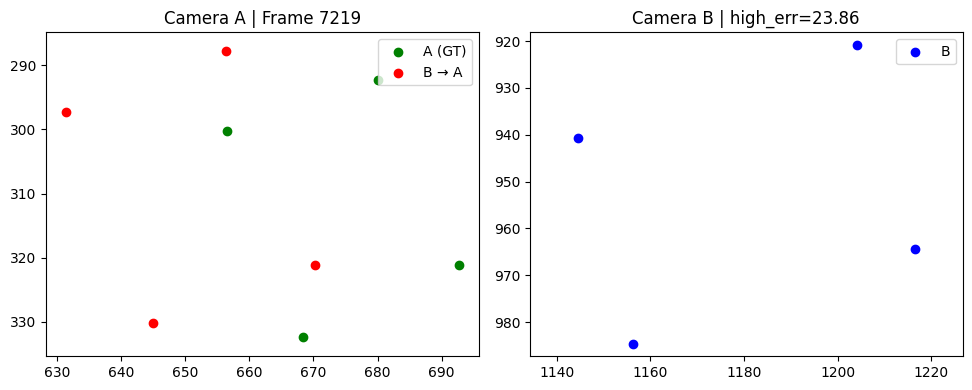

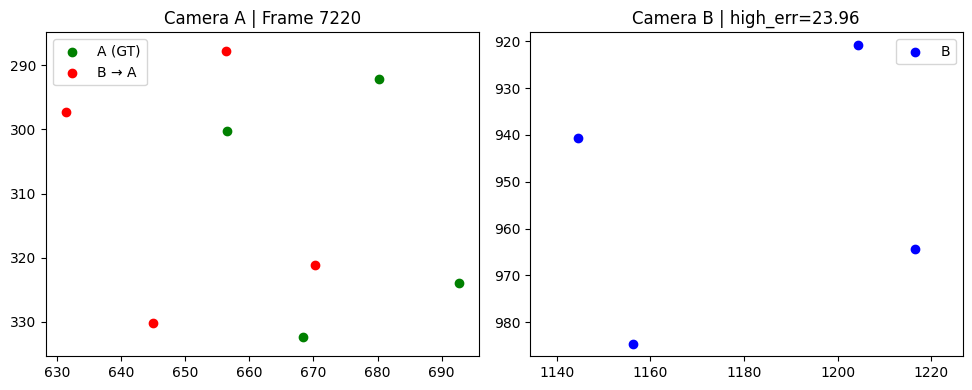

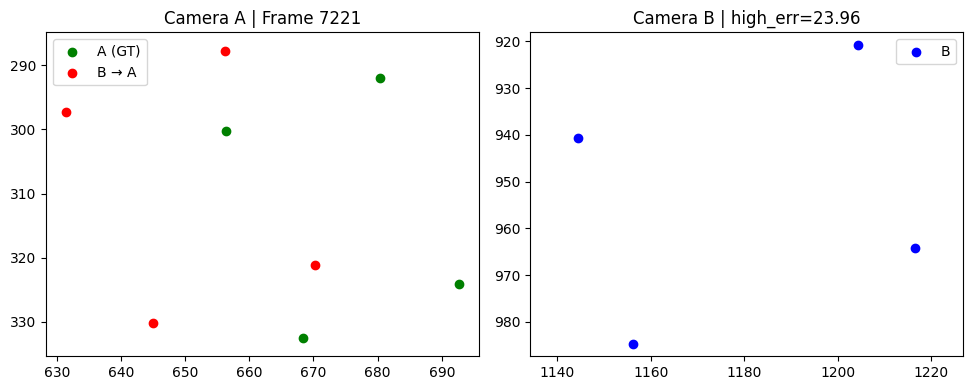

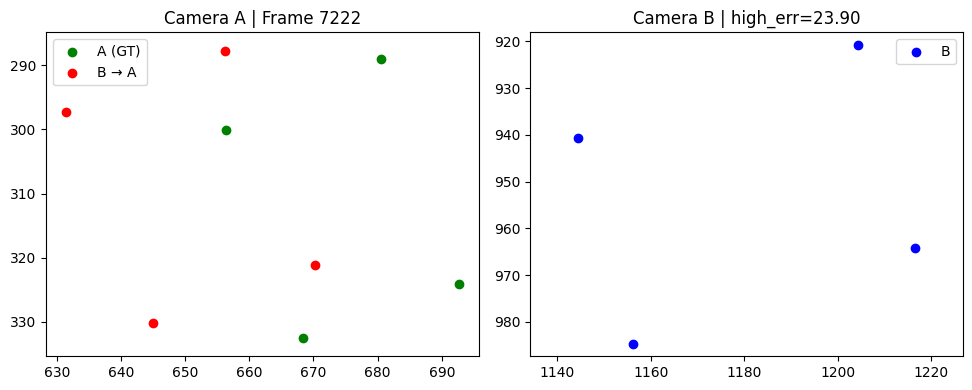

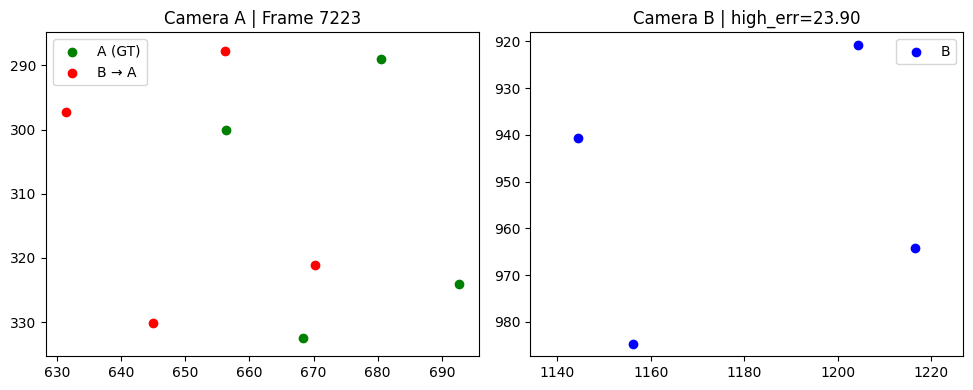

Rejected: high reprojection error (7.43px)
Failed for CameraSouth

Processing: CameraTop → CameraNorth

===== CARD EXTRACTION SUMMARY =====
Total frames:        18168
Kept frames:         6638
Removed (no inst):   0
Removed (low conf):  11530
Removed (missing):   0


===== CARD EXTRACTION SUMMARY =====
Total frames:        8272
Kept frames:         4466
Removed (no inst):   0
Removed (low conf):  3806
Removed (missing):   0

Common frames: 2299
Valid paired frames: 2299
Subsampled to: 500 frames
Inlier ratio: 0.40

Total common frames: 2299

Reprojection error stats:
Mean: 4.67
Median: 3.61
Max: 19.65
Min: 1.37

Bad frames found: 185
Frame: (2491, 'high_err=12.55')
Frame: (2492, 'high_err=12.56')
Frame: (2493, 'high_err=13.14')
Frame: (2494, 'high_err=13.17')
Frame: (2495, 'high_err=13.17')
Frame: (2496, 'high_err=13.16')
Frame: (2503, 'high_err=12.48')
Frame: (2504, 'high_err=12.74')
Frame: (2505, 'high_err=12.46')
Frame: (2506, 'high_err=13.08')
Mean reprojection error: 3487.08px
Bad

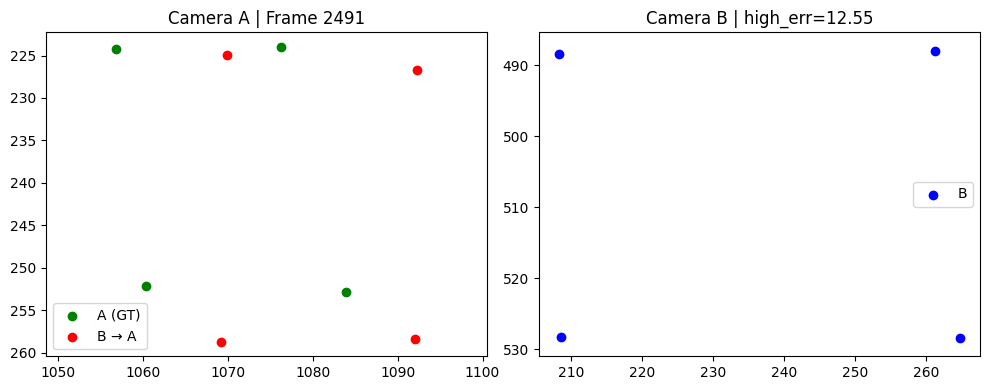

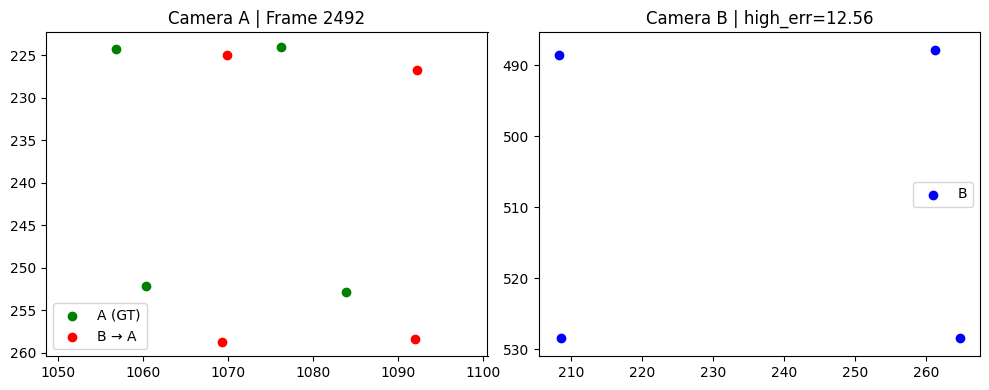

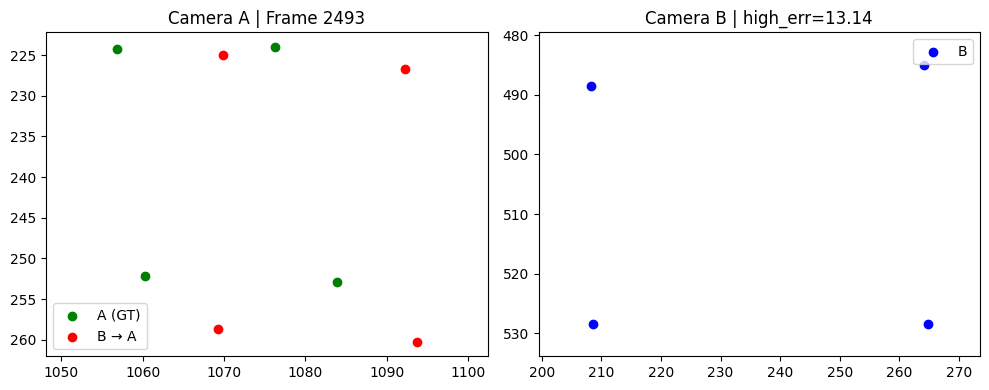

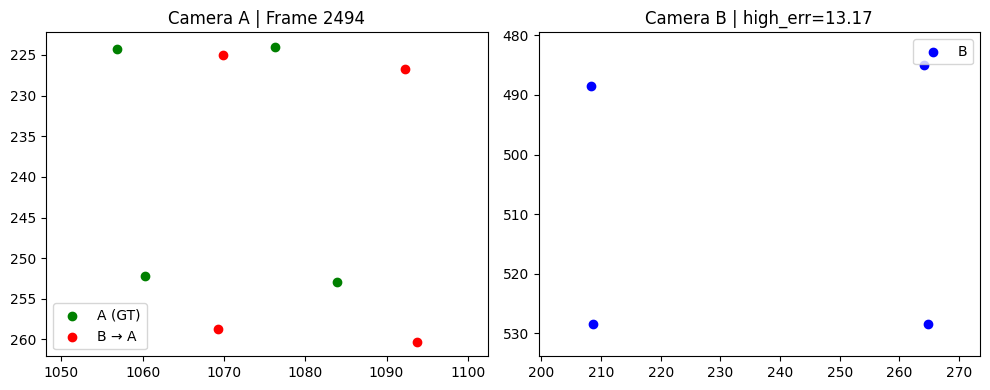

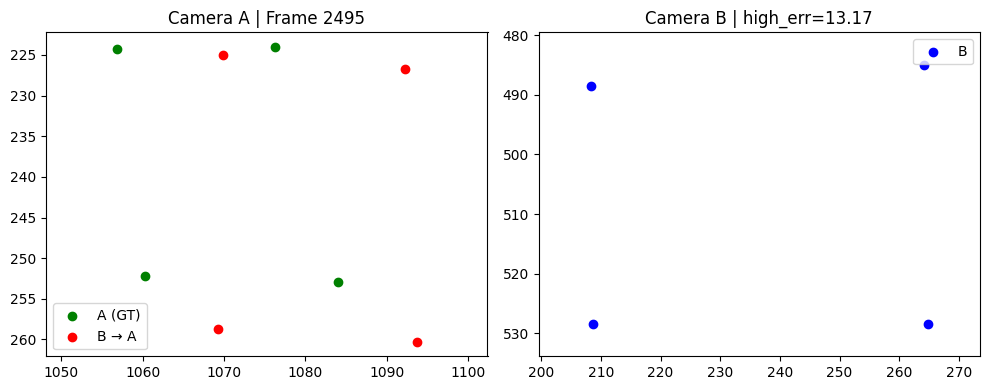


===== FINAL HOMOGRAPHY =====
[[-4.11240985e-03 -6.69603073e-01  1.34987358e+03]
 [ 5.60362943e-01 -7.69358881e-02  1.33002996e+02]
 [ 5.87484179e-06 -1.34465146e-04  1.00000000e+00]]
Mean reprojection error: 4.67px
Inlier ratio: 0.40
Frames used: 2299

Saved homography for CameraNorth in relation to CameraTop

Processing: CameraTop → CameraEast

===== CARD EXTRACTION SUMMARY =====
Total frames:        18168
Kept frames:         6638
Removed (no inst):   0
Removed (low conf):  11530
Removed (missing):   0


===== CARD EXTRACTION SUMMARY =====
Total frames:        8148
Kept frames:         4257
Removed (no inst):   0
Removed (low conf):  3891
Removed (missing):   0

Common frames: 3137
Valid paired frames: 3137
Subsampled to: 500 frames
Inlier ratio: 0.39

Total common frames: 3137

Reprojection error stats:
Mean: 4.37
Median: 3.64
Max: 11.15
Min: 0.98

Bad frames found: 73
Frame: (1878, 'high_err=11.08')
Frame: (1879, 'high_err=11.13')
Frame: (1880, 'high_err=10.56')
Frame: (1881, 'hig

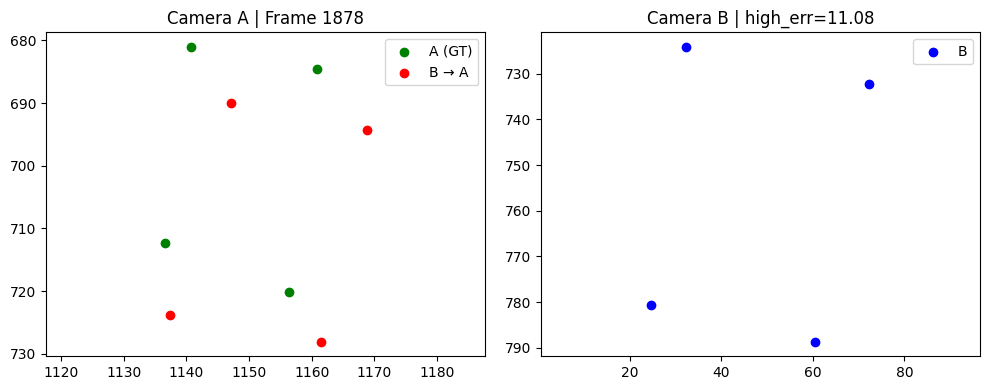

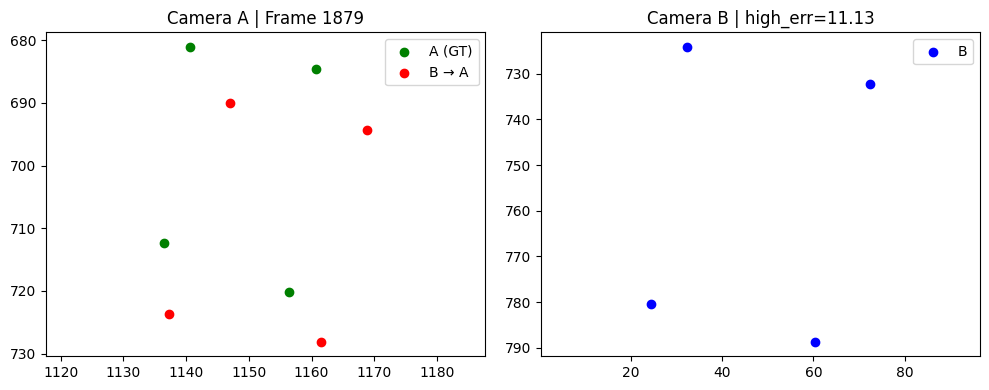

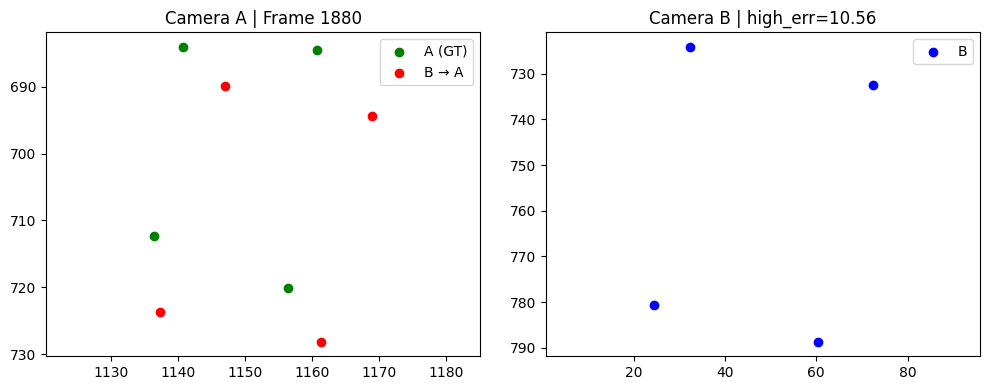

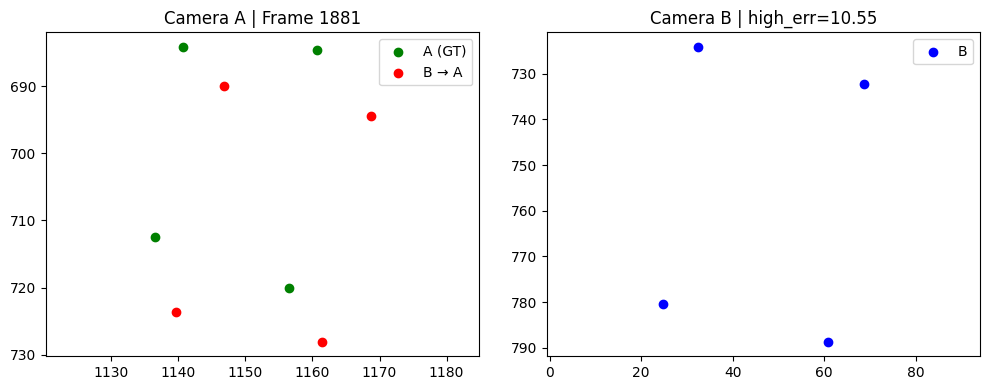

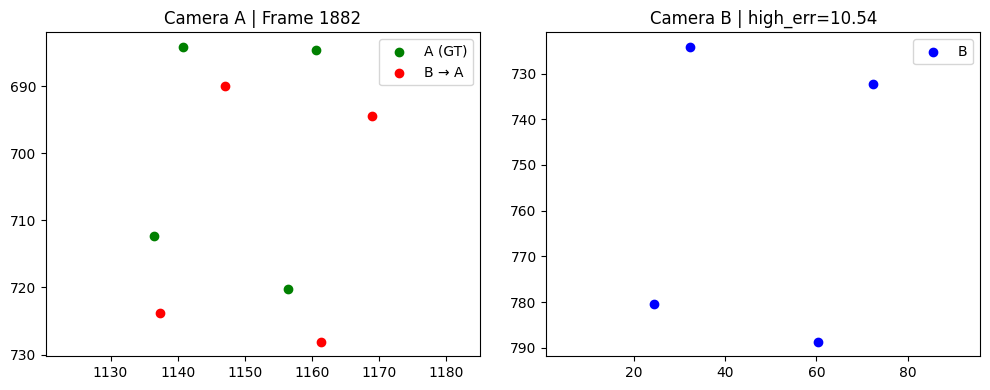


===== FINAL HOMOGRAPHY =====
[[-5.41067170e-01 -9.87646504e-02  1.14956342e+03]
 [ 2.27584539e-02 -6.28160686e-01  1.11897082e+03]
 [ 1.50199928e-05 -1.20661705e-04  1.00000000e+00]]
Mean reprojection error: 4.37px
Inlier ratio: 0.39
Frames used: 3137

Saved homography for CameraEast in relation to CameraTop

Processing: CameraTop → CameraWest

===== CARD EXTRACTION SUMMARY =====
Total frames:        18168
Kept frames:         6638
Removed (no inst):   0
Removed (low conf):  11530
Removed (missing):   0


===== CARD EXTRACTION SUMMARY =====
Total frames:        8008
Kept frames:         4110
Removed (no inst):   0
Removed (low conf):  3898
Removed (missing):   0

Common frames: 2470
Valid paired frames: 2470
Subsampled to: 500 frames
Inlier ratio: 0.36

Total common frames: 2470

Reprojection error stats:
Mean: 10.23
Median: 3.59
Max: 38.44
Min: 0.80

Bad frames found: 790
Frame: (2129, 'high_err=38.44')
Frame: (2130, 'high_err=37.90')
Frame: (2131, 'high_err=37.92')
Frame: (2132, 'hi

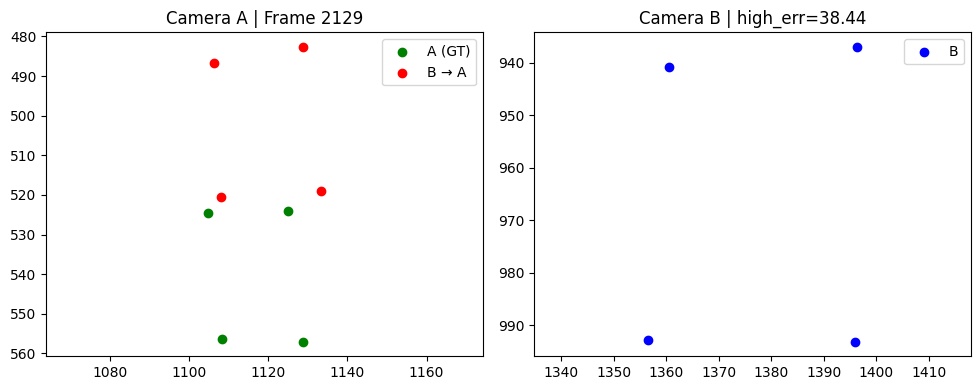

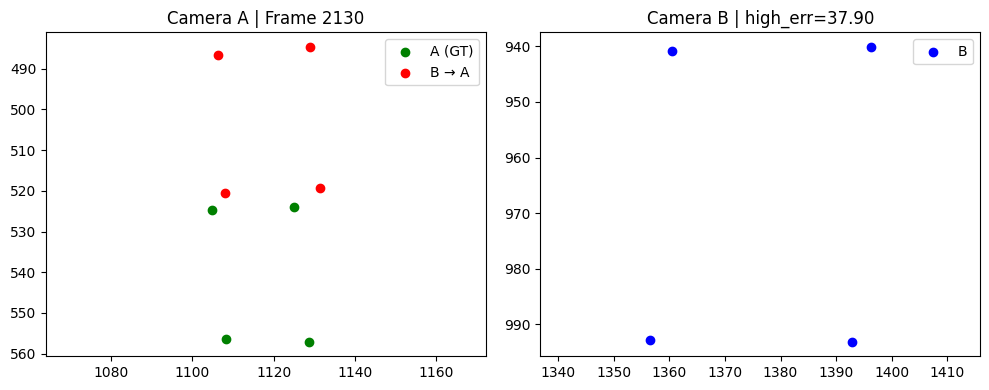

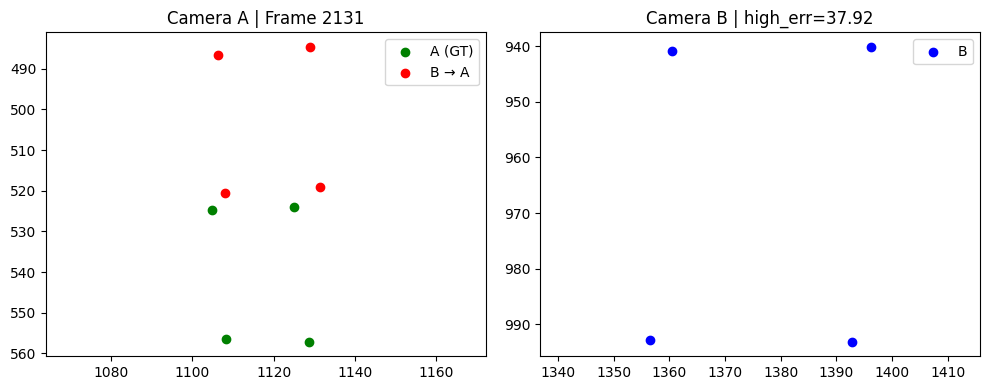

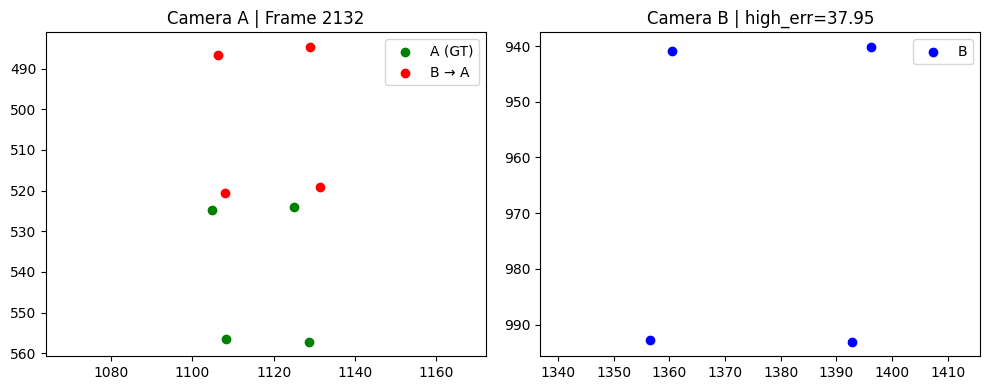

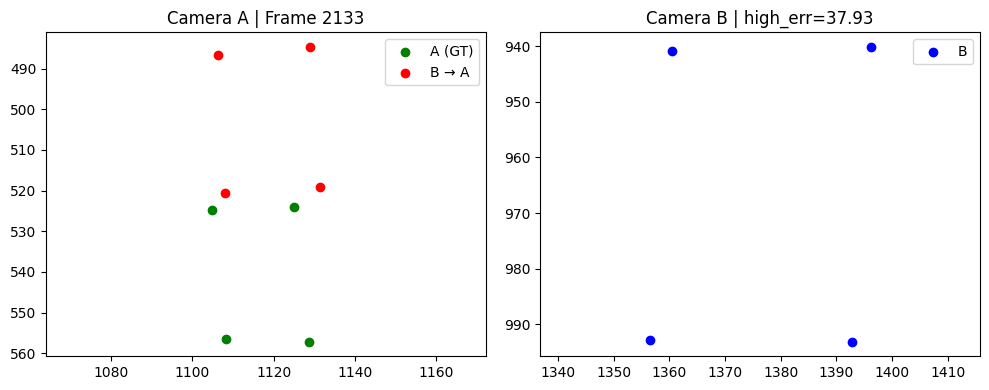

Rejected: high reprojection error (10.23px)
Failed for CameraWest


In [209]:
label_base_path = base_path_personal + f'/aeon3_data/{experiment}_sleap_for_card/models/card_inference_results/predictions'

labeled_video_a = find_sleap_file(
    label_base_path,
    camera_a,
    chunk,
    experiment
)

labels_a = sleap_io.load_file(labeled_video_a)

for camera_b in camera_b_list:

    labeled_video_b = find_sleap_file(
        label_base_path,
        camera_b,
        chunk,
        experiment
    )

    labels_b = sleap_io.load_file(labeled_video_b)

    print(f"\nProcessing: {camera_a} → {camera_b}")
    
    H = run_sleap_homography(
        labels_a,
        labels_b,
        camera_b
    )

    if H is None:
        print(f"Failed for {camera_b}")
        continue

    np.save(os.path.join(results_dir, f"H_{camera_a}_to_{camera_b}.npy"), H)

    print(f"Saved homography for {camera_b} in relation to {camera_a}")